SVM CLASSIFIER - PNEUMONIA DETECTION

📂 Loading dataset...
✅ Loaded: 4102 rows × 203 columns

📋 First 5 rows:
                   Image_Name  Label      Class  Feature_1  Feature_2  \
0  BACTERIA-5132924-0001.jpeg      1  Pneumonia -11.545157 -13.717647   
1  BACTERIA-1777631-0001.jpeg      1  Pneumonia  20.818638   8.152621   
2  BACTERIA-7392124-0001.jpeg      1  Pneumonia  30.078508   9.970522   
3  BACTERIA-9072988-0007.jpeg      1  Pneumonia -19.790420  16.773912   
4  BACTERIA-7560163-0001.jpeg      1  Pneumonia -26.874071 -19.328613   

   Feature_3  Feature_4  Feature_5  Feature_6  Feature_7  ...  Feature_191  \
0   2.459949  14.375765  19.150570  -8.340388   6.690397  ...    -2.288996   
1  -1.169066  15.593989   2.154690  18.117068 -13.609882  ...    -2.427195   
2  33.507303 -23.685114  -2.529166  -7.976503 -12.485124  ...    -3.986868   
3  12.641352  25.069962  -2.071930   3.694015   5.166889  ...     0.148843   
4   0.139244  19.195918   3.973868  -8.645415 -20.761864  ...

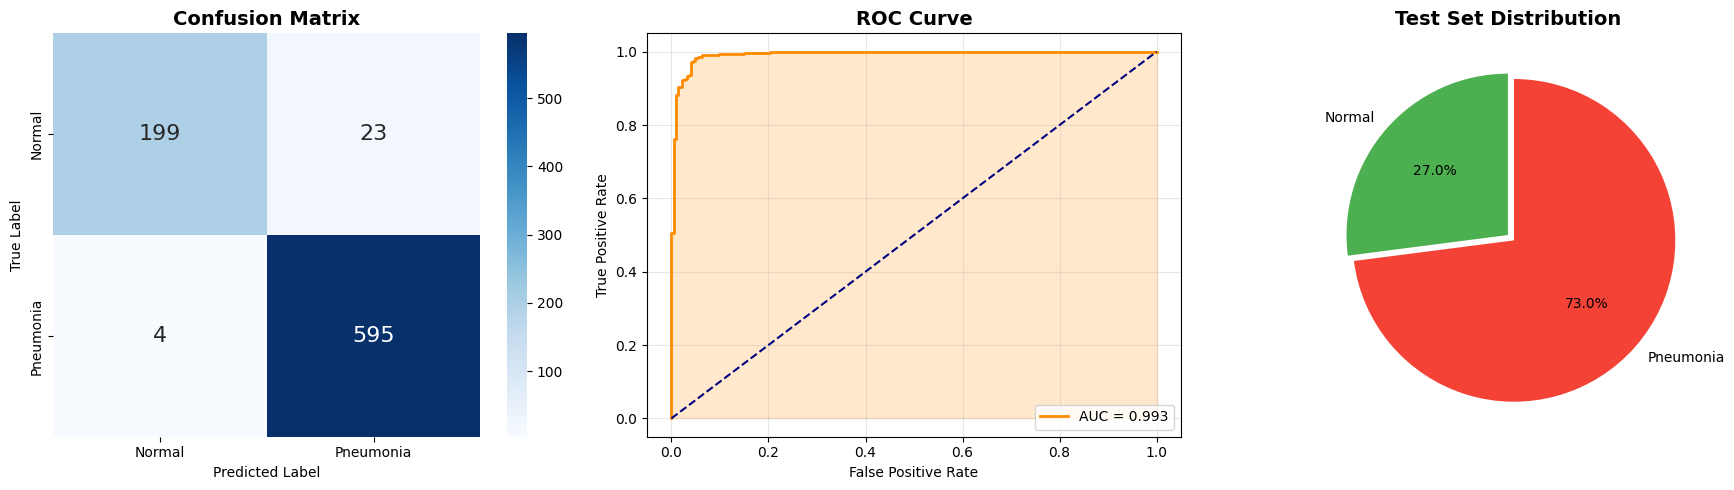


MODEL SUMMARY

🔧 SVM Parameters:
   Kernel:  rbf
   C:       10
   Gamma:   scale
   Support Vectors: [ 570 1054]

📈 Final Test Performance:
   Accuracy:   0.9671
   Precision:  0.9628
   Recall:     0.9933
   F1-Score:   0.9778
   AUC-ROC:    0.9928

✅ SVM CLASSIFICATION COMPLETE!


In [4]:
# ============================================
# SVM CLASSIFIER - DIRECT FROM CSV
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                           accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("SVM CLASSIFIER - PNEUMONIA DETECTION")
print("="*60)

# ============================================
# 1. LOAD THE CSV DATASET
# ============================================

csv_path = '/kaggle/input/datasets/mtishakil/chest-x-ray-feature-extracted-dataset-for-ml/Chest X-Ray Feature Extracted Dataset for ML.csv'

print(f"\n📂 Loading dataset...")
df = pd.read_csv(csv_path)
print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# Display first 5 rows
print(f"\n📋 First 5 rows:")
print(df.head())

# Check columns
print(f"\n📊 Columns: {list(df.columns[:10])}...")

# ============================================
# 2. EXPLORE DATA
# ============================================

print(f"\n📊 Class Distribution:")
print(df['Class'].value_counts())
print(f"\n   Normal:     {len(df[df['Label']==0])}")
print(f"   Pneumonia:  {len(df[df['Label']==1])}")

# ============================================
# 3. PREPARE FEATURES AND TARGET
# ============================================

print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)

# Drop non-feature columns
X = df.drop(['Image_Name', 'Label', 'Class'], axis=1)
y = df['Label']

print(f"\n✅ Features: {X.shape[1]} columns")
print(f"✅ Target: {len(y)} samples")

# ============================================
# 4. TRAIN-TEST SPLIT
# ============================================

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\n✅ Training: {len(X_train)} samples")
print(f"   Normal: {np.sum(y_train==0)}, Pneumonia: {np.sum(y_train==1)}")
print(f"✅ Testing:  {len(X_test)} samples")
print(f"   Normal: {np.sum(y_test==0)}, Pneumonia: {np.sum(y_test==1)}")

# ============================================
# 5. FEATURE SCALING
# ============================================

print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled")

# ============================================
# 6. TRAIN SVM
# ============================================

print("\n" + "="*60)
print("TRAINING SVM")
print("="*60)

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

print("⏳ Training SVM...")
svm_model.fit(X_train_scaled, y_train)
print("✅ Training complete!")

# ============================================
# 7. EVALUATE
# ============================================

print("\n" + "="*60)
print("RESULTS")
print("="*60)

y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob[:, 1])

print(f"\n📊 Test Performance:")
print(f"   Accuracy:   {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   Precision:  {precision:.4f} ({precision*100:.1f}%)")
print(f"   Recall:     {recall:.4f} ({recall*100:.1f}%)")
print(f"   F1-Score:   {f1:.4f} ({f1*100:.1f}%)")
print(f"   AUC-ROC:    {auc:.4f} ({auc*100:.1f}%)")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))

# ============================================
# 8. CONFUSION MATRIX & MEDICAL METRICS
# ============================================

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n🏥 Medical Metrics:")
print(f"   Correct Normal:     {tn}")
print(f"   False Alarms:       {fp}")
print(f"   Missed Pneumonia:   {fn} {'⚠️' if fn>0 else '✅'}")
print(f"   Caught Pneumonia:   {tp}")
print(f"   Sensitivity:        {tp/(tp+fn):.4f} ({tp/(tp+fn)*100:.1f}%)")
print(f"   Specificity:        {tn/(tn+fp):.4f} ({tn/(tn+fp)*100:.1f}%)")

# ============================================
# 9. VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='navy')
axes[1].fill_between(fpr, tpr, alpha=0.2, color='darkorange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# Class Distribution
class_counts = [np.sum(y_test==0), np.sum(y_test==1)]
axes[2].pie(class_counts, labels=['Normal', 'Pneumonia'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], explode=(0, 0.05), startangle=90)
axes[2].set_title('Test Set Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 10. SUMMARY
# ============================================

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)

print(f"\n🔧 SVM Parameters:")
print(f"   Kernel:  {svm_model.kernel}")
print(f"   C:       {svm_model.C}")
print(f"   Gamma:   {svm_model.gamma}")
print(f"   Support Vectors: {svm_model.n_support_}")

print(f"\n📈 Final Test Performance:")
print(f"   Accuracy:   {accuracy:.4f}")
print(f"   Precision:  {precision:.4f}")
print(f"   Recall:     {recall:.4f}")
print(f"   F1-Score:   {f1:.4f}")
print(f"   AUC-ROC:    {auc:.4f}")

print("\n" + "="*60)
print("✅ SVM CLASSIFICATION COMPLETE!")
print("="*60)